### Drift Measurement

### 1. Indicator Effectiveness Analysis

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt

In [2]:
import pandas as pd
from scipy.stats import spearmanr

# --- 1. Load datasets ---
cade = pd.read_csv("../data/res/cade.csv")
enidrift = pd.read_csv("../data/res/enidrift.csv")   
chen = pd.read_csv("../data/res/chen.csv")
entropy = pd.read_csv("../data/res/static/static8.csv") 
lmt = pd.read_csv("../data/res/static/static8.csv") 

# --- 2. Extract (score, metrics) pairs ---
methods = {
    "CADE": (cade["drift_cade_score"], cade),
    "ENIDRIFT": (enidrift["drift_gidx_score"], enidrift),
    "CHEN": (chen["drift_chen_score"], chen),
    "Entropy(LANTERN)": (entropy["entropy_score"], entropy),
    "LMT(LANTERN)": (lmt["lmt_mean_score"], lmt),
}

metrics = ["accuracy", "f1_score", "precision", "recall"]

# --- 3. Compute Spearman correlation (ρ, p) ---
rows = []
for method, (score, df) in methods.items():
    for m in metrics:
        # drop NaN
        valid = df[[m]].dropna().index.intersection(score.dropna().index)
        rho, p = spearmanr(score.loc[valid], df.loc[valid, m])
        rows.append({
            "Method": method,
            "Metric": m,
            "Corr": rho,
            "p_value": p
        })

# --- 4. Format summary table ---
results = pd.DataFrame(rows)
pivot = results.pivot(index="Method", columns="Metric", values=["Corr", "p_value"])
pivot.columns = [f"{a}({b})" for a,b in pivot.columns]
pivot = pivot.reset_index()

# --- 5. Display neatly ---
pd.set_option('display.float_format', lambda x: f"{x:.3f}")
print(pivot)


             Method  Corr(accuracy)  Corr(f1_score)  Corr(precision)  \
0              CADE          -0.728          -0.719           -0.717   
1              CHEN          -0.660          -0.628           -0.622   
2          ENIDRIFT          -0.791          -0.714           -0.705   
3  Entropy(LANTERN)          -0.760          -0.751           -0.734   
4      LMT(LANTERN)          -0.879          -0.827           -0.799   

   Corr(recall)  p_value(accuracy)  p_value(f1_score)  p_value(precision)  \
0        -0.687              0.000              0.000               0.000   
1        -0.617              0.000              0.000               0.000   
2        -0.699              0.000              0.000               0.000   
3        -0.727              0.000              0.000               0.000   
4        -0.813              0.000              0.000               0.000   

   p_value(recall)  
0            0.000  
1            0.000  
2            0.000  
3            0.000  

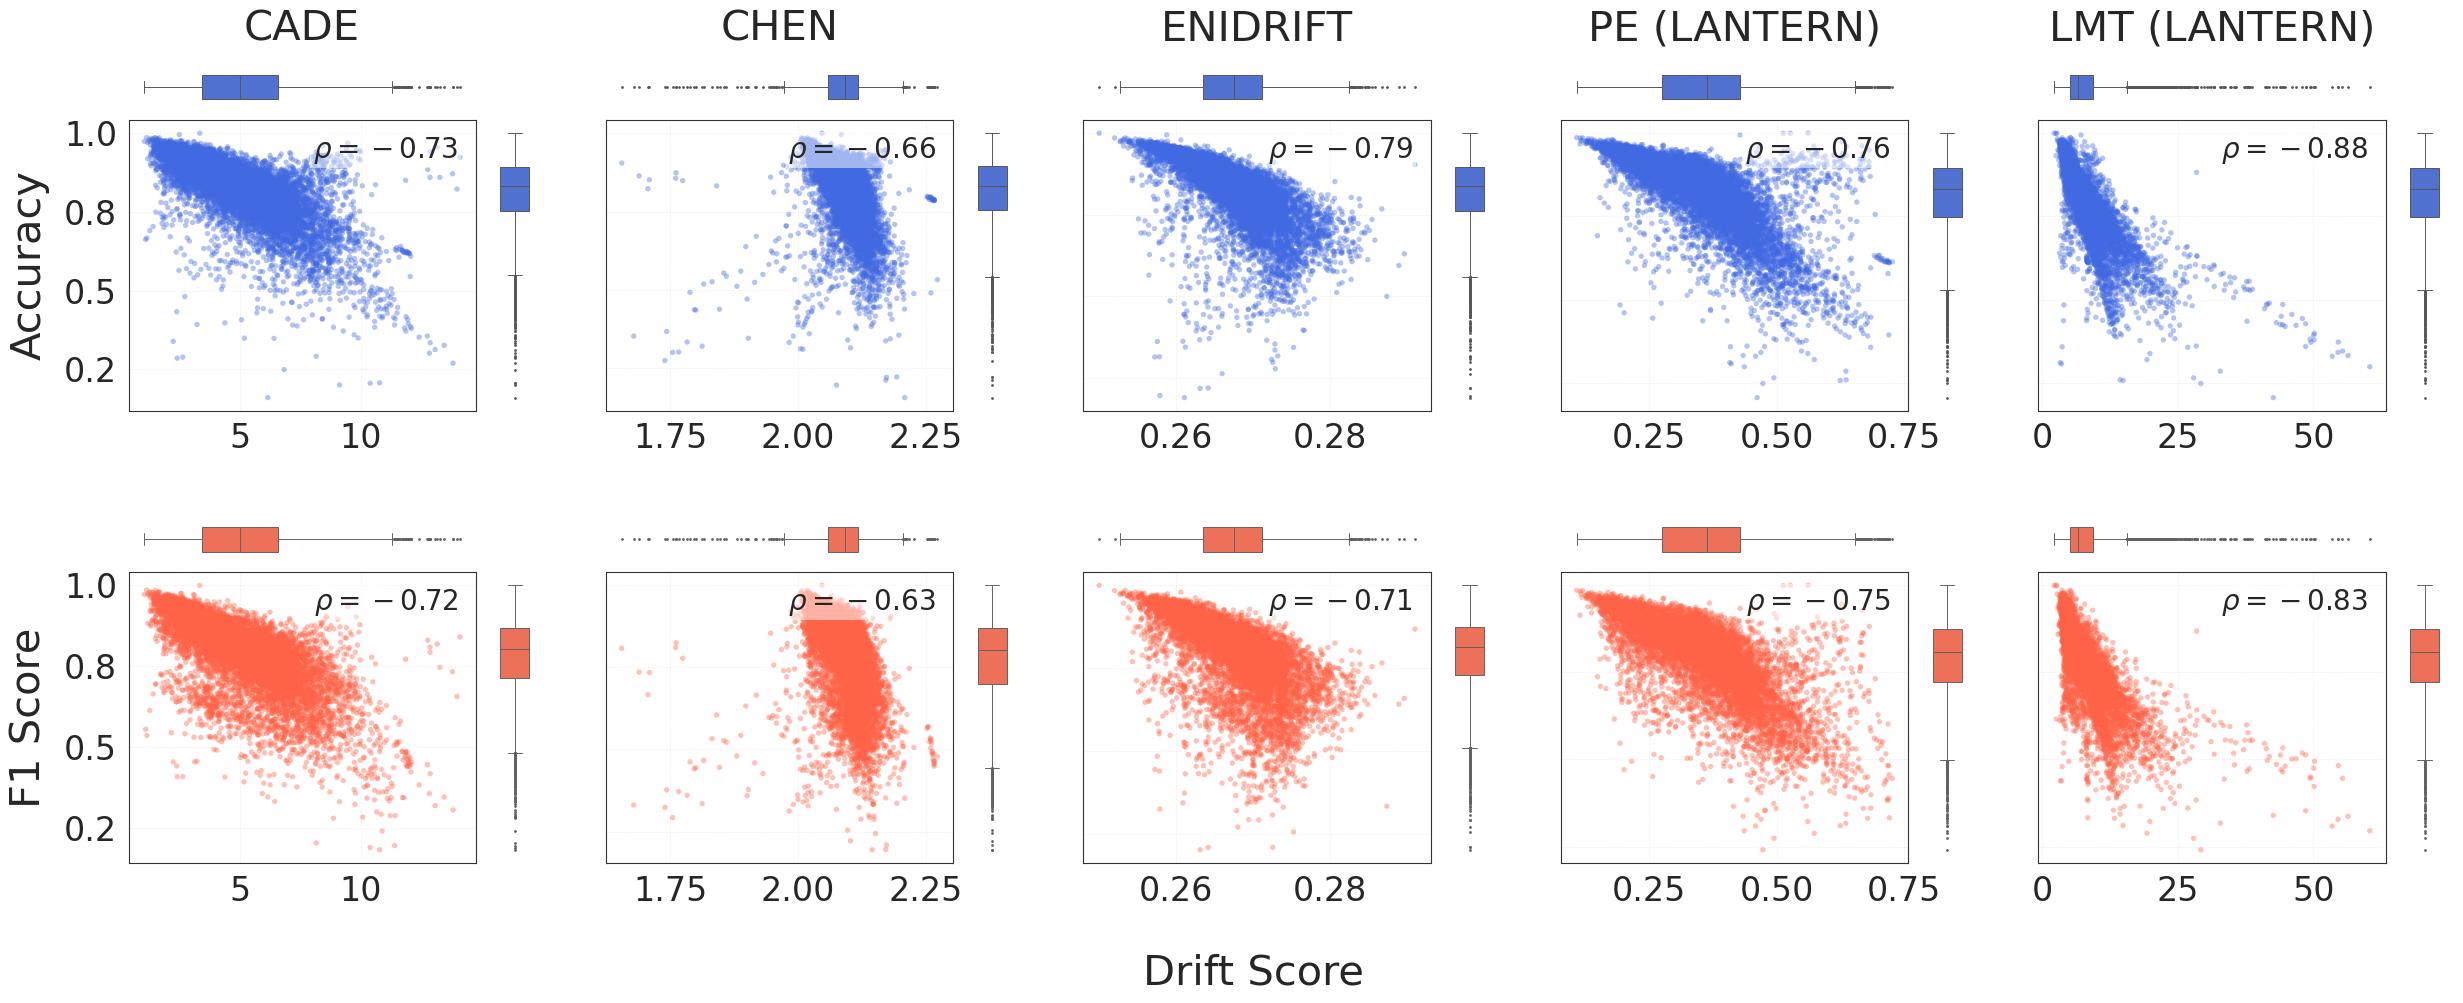

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import gridspec
from matplotlib.ticker import MaxNLocator, FormatStrFormatter
from scipy.stats import spearmanr

# ---------------------------------------------------
# Load and organize data
# ---------------------------------------------------
methods = {
    "CADE":    ("drift_cade_score", cade),
    "CHEN":    ("drift_chen_score", chen),
    "ENIDRIFT": ("drift_gidx_score", enidrift),
    "PE (LANTERN)": ("entropy_score", entropy),
    "LMT (LANTERN)":     ("lmt_mean_score", lmt),
}

# ---------------------------------------------------
# Style setup
# ---------------------------------------------------
sns.set(style="whitegrid", context="paper")
plt.rcParams.update({
    #"font.family": "serif",     # Often preferred in standard papers
    "axes.labelsize": 30,       # Moderate size for subplots
    "xtick.labelsize": 24,
    "ytick.labelsize": 24,
    "axes.linewidth": 0.8,
    "axes.edgecolor": ".2",
    "grid.alpha": 0.3,
    "legend.fontsize": 20
})

# ---------------------------------------------------
# Set up figure (2 rows × 7 columns)
# ---------------------------------------------------
#fig = plt.figure(figsize=(25, 7))
#outer = gridspec.GridSpec(2, 7, wspace=0.45, hspace=0.65) 

# ---------------------------------------------------
# Helper to plot scatter + marginal boxplots
# ---------------------------------------------------
def scatter_with_box(fig, position, df, x_col, y_col, color, 
                     show_yaxis=False, show_xaxis_ticks=True, logx=False):
    """
    Creates a scatter plot with marginal boxplots, customized for cleanliness.
    """
    # Grid: Boxplots take 15% of space, scatter takes rest
    inner = gridspec.GridSpecFromSubplotSpec(
        2, 2, subplot_spec=position,
        width_ratios=[6, 1], height_ratios=[1, 6],
        wspace=0.05, hspace=0.05
    )

    # --- Main scatter plot ---
    ax_main = plt.Subplot(fig, inner[1, 0])
    fig.add_subplot(ax_main)
    
    # Calculate correlation (ignoring NaNs)
    valid_data = df[[x_col, y_col]].dropna()
    if len(valid_data) > 1:
        rho, _ = spearmanr(valid_data[x_col], valid_data[y_col])
        corr_text = fr"$\rho = {rho:.2f}$"
    else:
        corr_text = "N/A"

    sns.scatterplot(
        data=df, x=x_col, y=y_col, ax=ax_main,
        s=15, alpha=0.4, color=color, edgecolor="none", rasterized=True # rasterized=True helps reduce PDF size with many points
    )
    
    if logx:
        ax_main.set_xscale("log")

    # Clean up main axes
    ax_main.set_xlabel("")
    ax_main.set_ylabel("")
    ax_main.grid(True, which='major', linestyle='--', linewidth=0.5)
    
    # Add correlation text to top-right corner
    ax_main.text(0.95, 0.95, corr_text, transform=ax_main.transAxes, 
                 ha='right', va='top', fontsize=20,
                 bbox=dict(facecolor='white', alpha=0.5, edgecolor='none', pad=2))

    # Handle Ticks Visibility
    if not show_yaxis:
        plt.setp(ax_main.get_yticklabels(), visible=False)
    else:
        ax_main.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
        
    if not show_xaxis_ticks:
        # Optional: if you want to hide x-ticks for rows that aren't the bottom
        # (Not strictly applied here as we only have one row per metric)
        pass

    # --- Top marginal boxplot (X distribution) ---
    ax_x = plt.Subplot(fig, inner[0, 0], sharex=ax_main)
    fig.add_subplot(ax_x)
    sns.boxplot(data=df, x=x_col, ax=ax_x, color=color, 
                width=0.5, fliersize=1, linewidth=0.7, saturation=0.8)
    ax_x.axis("off")

    # --- Right marginal boxplot (Y distribution) ---
    ax_y = plt.Subplot(fig, inner[1, 1], sharey=ax_main)
    fig.add_subplot(ax_y)
    sns.boxplot(data=df, y=y_col, ax=ax_y, color=color, 
                width=0.5, fliersize=1, linewidth=0.7, saturation=0.8)
    ax_y.axis("off")

    return ax_main

# ---------------------------------------------------
# 4. Main Plotting Routine
# ---------------------------------------------------
# Define figure - slightly taller to accommodate bottom label comfortably
fig = plt.figure(figsize=(25, 10)) 
# Adjust hspace/wspace for tighter but readable layout
outer = gridspec.GridSpec(2, 5, wspace=0.15, hspace=0.3, 
                          left=0.05, right=0.98, top=0.92, bottom=0.12)

font_main=30
font_extra=26

metrics = [
    ("accuracy", "Accuracy", "royalblue"),
    ("f1_score", "F1 Score", "tomato")
]
ylabel_axes = []

for row_idx, (metric_col, metric_name, color) in enumerate(metrics):
    for col_idx, (method_name, (score_col, df)) in enumerate(methods.items()):
        if score_col not in df.columns:
             continue

        # Determine specific settings for this plot
        is_first_col = (col_idx == 0)
        use_log_x = method_name in ["Mateen", "OWAD"]
        
        # Get subplot position
        pos = outer[row_idx, col_idx]
        
        # Draw the plot
        ax = scatter_with_box(
            fig, pos, df, score_col, metric_col, color,
            show_yaxis=is_first_col, logx=use_log_x
        )
        
        # --- Custom adjustments per method ---
        # Fix Entropy's crowded X-ticks if not log scale
        if method_name == "Entropy" and not use_log_x:
            ax.xaxis.set_major_locator(MaxNLocator(nbins=3))

        # --- Labels & Titles ---
        # Row labels (on the far left of the first column)
        if is_first_col:
            ax.set_ylabel(metric_name, fontsize=font_main, fontweight='medium', labelpad=10)
            ylabel_axes.append(ax)
            
        # Column titles (only above the top row)
        if row_idx == 0:
            # Use fig.text for easier centering relative to the outer grid slot
            bbox = ax.get_position()
            fig.text(bbox.x0 + bbox.width/2, bbox.y1 + 0.07, method_name, 
                     ha="center", va="bottom", fontsize=font_main, fontweight='medium')

# ---------------------------------------------------
# 5. Final Global Labels & Saving
# ---------------------------------------------------
fig.align_ylabels(ylabel_axes)
# Unified X-axis label at the bottom
fig.text(0.5, -0.01, 'Drift Score', ha='center', va='bottom', 
         fontsize=font_main)

# Save with high DPI for print quality
plt.savefig("../data/ana/drift_corr.pdf", dpi=300, bbox_inches="tight")
plt.show()

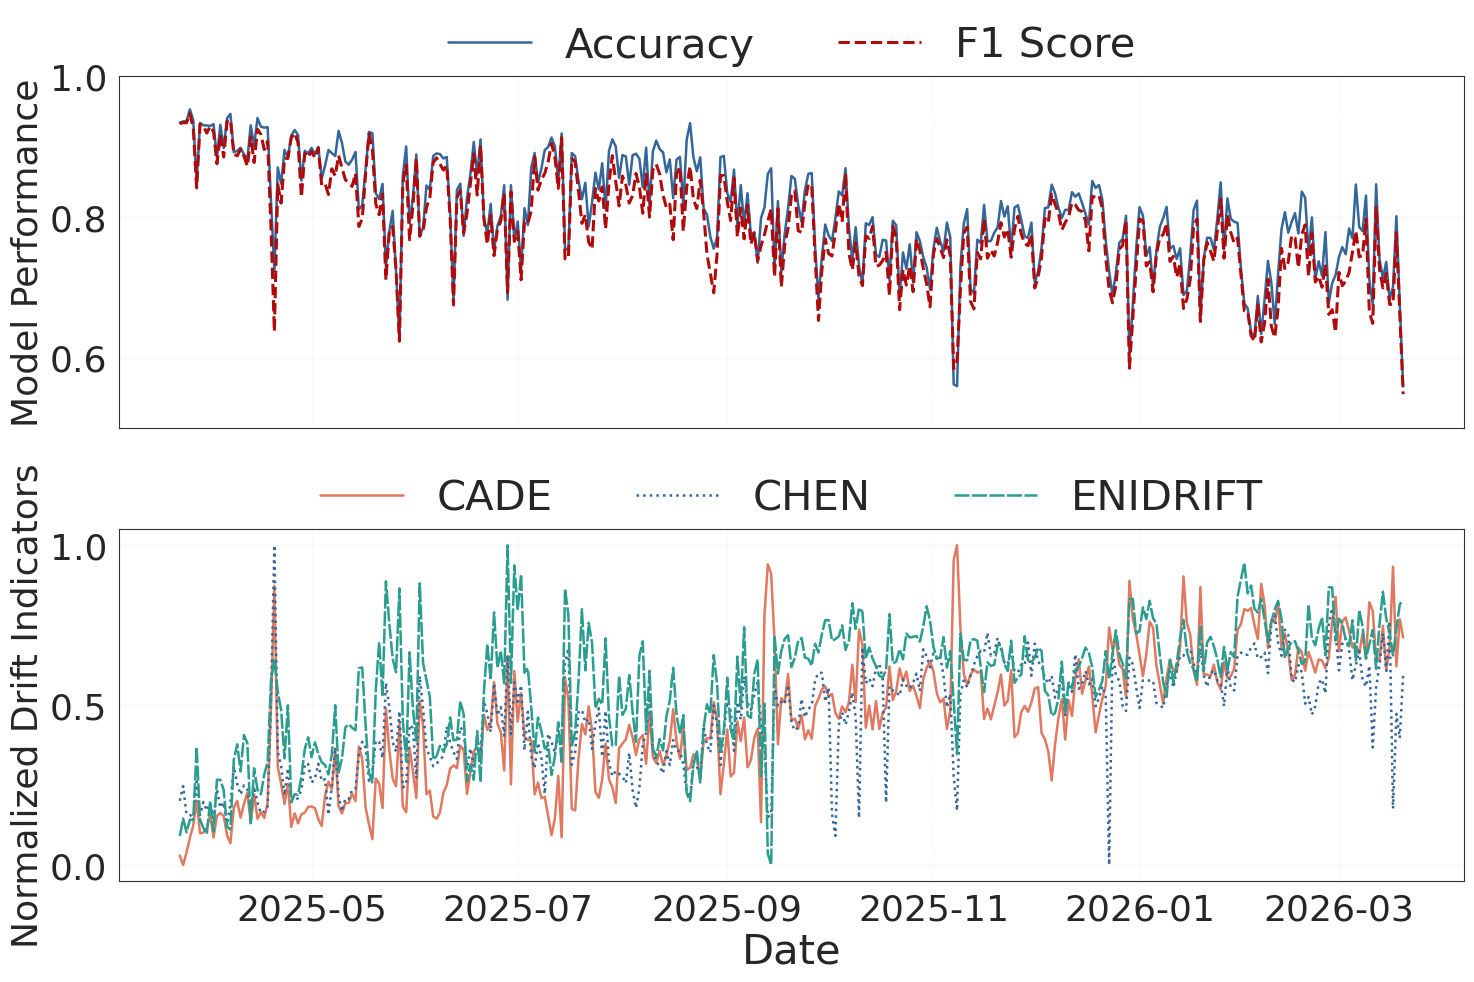

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Merge key columns ---
df = pd.DataFrame({
    "block_index": entropy["block_index"],
    "accuracy": entropy["accuracy"],
    "f1_score": entropy["f1_score"],
    "entropy": entropy["entropy_score"],
    "lmt": lmt["lmt_mean_score"],
    "cade": cade["drift_cade_score"],
    "chen": chen["drift_chen_score"],
    "enidrift": enidrift["drift_gidx_score"],
})

font_main=30
font_extra=26

# --- Convert block index to datetime (1 block = 1 hour) ---
start_time = pd.Timestamp("2025-03-15")
df["datetime"] = start_time + pd.to_timedelta(df["block_index"], unit="h")

# --- Restrict time range ---
df = df[(df["datetime"] >= "2025-03-15") & (df["datetime"] <= "2026-03-25")]

# --- Aggregate per day (24 blocks = 1 day) ---
df_day = (
    df.resample("1D", on="datetime")
      .mean(numeric_only=True)
      .reset_index()
)

# --- Normalize only drift indicators ---
for c in ["entropy", "lmt", "cade", "chen", "enidrift"]:
    df_day[c] = (df_day[c] - df_day[c].min()) / (df_day[c].max() - df_day[c].min())

# --- Create 2x1 subplots with shared x-axis ---
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(15, 10), sharex=True, gridspec_kw={"height_ratios": [1, 1]}
)

# === (1) Top: Model Performance ===
ax1.plot(df_day["datetime"], df_day["accuracy"],
         color="#34669A", linewidth=1.8, label="Accuracy")
ax1.plot(df_day["datetime"], df_day["f1_score"],
         color="#B00A0B", linewidth=2.2, linestyle="--", label="F1 Score")


ax1.set_ylabel("Model Performance", fontsize=font_extra)
ax1.set_ylim(0.5, 1)
ax1.grid(alpha=0.3, linestyle="--", linewidth=0.5)

# Top legend (above first subplot)
ax1.legend(loc="upper center", bbox_to_anchor=(0.5, 1.25),
           ncol=2, frameon=False, fontsize=font_main)

# === (2) Bottom: Normalized Drift Indicators ===
ax2.plot(df_day["datetime"], df_day["cade"],
         color="#E0795F", linestyle="solid", linewidth=1.8, label="CADE")
ax2.plot(df_day["datetime"], df_day["chen"],
         color="#34669A", linestyle=":", linewidth=1.8, label="CHEN")

ax2.plot(df_day["datetime"], df_day["enidrift"],
            color="#299d8f", linestyle=(0, (6, 1)), linewidth=1.8, label="ENIDRIFT")
'''
ax2.plot(df_day["datetime"], df_day["entropy"],
         color="royalblue", linestyle="solid", linewidth=1.8, label="PE (LANTERN)")
ax2.plot(df_day["datetime"], df_day["lmt"],
         color="tomato", linestyle="-.", linewidth=1.8, label="LMT (LANTERN)")
'''

ax2.set_ylabel("Normalized Drift Indicators", fontsize=font_extra)
ax2.set_xlabel("Date", fontsize=font_main)
ax2.grid(alpha=0.3, linestyle="--", linewidth=0.5)

# Bottom legend (above second subplot)
ax2.legend(loc="upper center", bbox_to_anchor=(0.5, 1.25),
           ncol=3, frameon=False, fontsize=30)

# --- Shared formatting ---
plt.xticks(rotation=0)
fig.tight_layout(rect=[0, 0, 1, 0.99])

# Increase tick label font sizes
ax1.tick_params(axis='both', which='major', labelsize=font_extra)
ax2.tick_params(axis='both', which='major', labelsize=font_extra)

plt.savefig("../data/ana/drift_indicators_over_time.pdf", bbox_inches="tight")
plt.show()


### 2. Drift Indicator Reliability Evaluation

In [5]:
# --- Compute adaptive global ground truth threshold ---
methods = [entropy, lmt, cade, chen, enidrift]  # include all loaded df
thresholds = []

for df in methods:
    thr = df["f1_score"].median() - 1.5 * df["f1_score"].std()
    thresholds.append(thr)
    print(f"{df.shape[0]:5d} blocks → F1 median/std = {df['f1_score'].median():.4f}/{df['f1_score'].std():.4f}, threshold = {thr:.4f}")

GROUND_TRUTH_THRESHOLD = np.mean(thresholds)
print(f"\n>>> Global ground truth threshold (mean across methods): {GROUND_TRUTH_THRESHOLD:.4f}")

 8704 blocks → F1 median/std = 0.8080/0.1145, threshold = 0.6363
 8704 blocks → F1 median/std = 0.8080/0.1145, threshold = 0.6363
 8704 blocks → F1 median/std = 0.8029/0.1169, threshold = 0.6276
 8704 blocks → F1 median/std = 0.8026/0.1268, threshold = 0.6124
 8704 blocks → F1 median/std = 0.8130/0.1134, threshold = 0.6429

>>> Global ground truth threshold (mean across methods): 0.6311


In [6]:
import pandas as pd
import numpy as np

# =====================================================
# 1. Parameters
# =====================================================
GROUND_TRUTH_THRESHOLD = 0.6311 # Define bad blocks (F1 < 0.7)
K_PERSISTENCE = 1            # For rolling confirmation (smooth alarm)

# =====================================================
# 2. Baseline reference statistics (median + MAD or mean + σ)
# =====================================================
BASE_STATS = {
    "CADE": {"median": 0.6733, "mad": 0.7003},
    "Chen": {"median": 1.9936, "mad": 0.0095},
    "enidrift": {"median": 0.2554, "mad": 0.0026},
    "Entropy": {"mu": 0.0953, "sigma": 0.1858},
    "LMT": {"median": 6.6422, "mad": 1.9628},
}

# =====================================================
# 3. Helper functions
# =====================================================
def get_robust_threshold(median, mad, k, direction="high"):
    mad = max(mad, abs(median) * 0.05 or 1e-9)
    return median + k * mad if direction == "high" else median - k * mad

def evaluate(df, drift_col, truth_col="ground_truth"):
    y_true = df[truth_col]   # Ground truth: F1 < threshold  Drift -> high score identified
    y_pred = df[drift_col]   

    TP = ((y_pred) & (y_true)).sum()
    FP = ((y_pred) & (~y_true)).sum()
    FN = ((~y_pred) & (y_true)).sum()
    TN = ((~y_pred) & (~y_true)).sum()
    total = TP + TN + FP + FN

    precision = TP / (TP + FP) if (TP + FP) else 0
    recall = TP / (TP + FN) if (TP + FN) else 0
    f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) else 0
    acc = (TP + TN) / total
    det_rate = 100 * y_pred.sum() / total

    mean_f1_drifted = df.loc[y_pred, "f1_score"].mean()
    mean_f1_clean = df.loc[~y_pred, "f1_score"].mean()

    return {
        "#Blocks": total, "#Drifts": y_pred.sum(), "Detection Rate(%)": det_rate,
        "Precision": precision, "Recall": recall, "acc": acc, "f1": f1,
        "mean_F1_drifted": mean_f1_drifted, "mean_F1_clean": mean_f1_clean,
        "FP": FP, "TP": TP
    }

# =====================================================
# 4. Evaluation per indicator (1.5σ vs 3.0σ)
# =====================================================
final_results = []

# --- Entropy (LANTERN) ---
df_entropy = entropy.copy()
df_entropy["ground_truth"] = df_entropy["f1_score"] < GROUND_TRUTH_THRESHOLD
print("Entropy: drift ratio =", (df_entropy["ground_truth"].mean()*100).round(2), "%")
mu, sigma = BASE_STATS["Entropy"]["mu"], BASE_STATS["Entropy"]["sigma"]

for k in [1.0, 2.0, 3.0]:
    th = mu + k * sigma
    df_entropy[f"entropy_{k}σ"] = df_entropy["entropy_score"] > th    # Detect drift if score > threshold
    res = evaluate(df_entropy, f"entropy_{k}σ")
    res["method"] = f"Entropy (LANTERN {k}σ)"
    final_results.append(res.copy())


# --- LMT (LANTERN) ---
df_lmt = lmt.copy()
df_lmt["ground_truth"] = df_lmt["f1_score"] < GROUND_TRUTH_THRESHOLD
med, mad = BASE_STATS["LMT"]["median"], BASE_STATS["LMT"]["mad"]

for k in [1.0, 2.0, 3.0]:
    th = get_robust_threshold(med, mad, k)
    df_lmt[f"lmt_{k}σ"] = df_lmt["lmt_mean_score"] > th
    res = evaluate(df_lmt, f"lmt_{k}σ")
    res["method"] = f"LMT (LANTERN {k}σ)"
    final_results.append(res.copy())

# --- CADE ---
df_cade = cade.copy()
df_cade["ground_truth"] = df_cade["f1_score"] < GROUND_TRUTH_THRESHOLD
med, mad = BASE_STATS["CADE"]["median"], BASE_STATS["CADE"]["mad"]

for k in [1.0, 2.0, 3.0]:
    th = get_robust_threshold(med, mad, k)
    df_cade[f"cade_{k}σ"] = df_cade["drift_cade_score"] > th
    res = evaluate(df_cade, f"cade_{k}σ")
    res["method"] = f"CADE (Baseline {k}σ)"
    final_results.append(res.copy())

# --- Chen ---
df_chen = chen.copy()
df_chen["ground_truth"] = df_chen["f1_score"] < GROUND_TRUTH_THRESHOLD
med, mad = BASE_STATS["Chen"]["median"], BASE_STATS["Chen"]["mad"]

for k in [1.0, 2.0, 3.0]:
    th = get_robust_threshold(med, mad, k, direction="high")
    df_chen[f"chen_{k}σ"] = df_chen["drift_chen_score"] > th
    res = evaluate(df_chen, f"chen_{k}σ")
    res["method"] = f"Chen (Baseline {k}σ)"
    final_results.append(res.copy())

# --- ENIDRIFT ---
df_enidrift = enidrift.copy()
df_enidrift["ground_truth"] = df_enidrift["f1_score"] < GROUND_TRUTH_THRESHOLD
med, mad = BASE_STATS["enidrift"]["median"], BASE_STATS["enidrift"]["mad"]

for k in [1.0, 2.0, 3.0]:
    th = get_robust_threshold(med, mad, k)
    df_enidrift[f"enidrift_{k}σ"] = df_enidrift["drift_gidx_score"] > th
    res = evaluate(df_enidrift, f"enidrift_{k}σ")
    res["method"] = f"ENIDrift (Baseline {k}σ)"
    final_results.append(res.copy())



# =====================================================
# 5. Final summary table
# =====================================================
summary = pd.DataFrame(final_results).set_index("method")
cols = ["#Blocks", "#Drifts", "Detection Rate(%)", "Precision", "Recall",
        "acc", "f1", "mean_F1_drifted", "mean_F1_clean", "FP", "TP"]
summary = pd.DataFrame([r.copy() for r in final_results]).set_index("method")
summary = summary[cols]

print("\n================ INDICATOR RELIABILITY ANALYSIS ================")
print(summary.to_string(float_format="%.4f"))
print("================================================================")


Entropy: drift ratio = 10.5 %

================ INDICATOR RELIABILITY ANALYSIS ================
                          #Blocks  #Drifts  Detection Rate(%)  Precision  Recall    acc     f1  mean_F1_drifted  mean_F1_clean    FP    TP
method                                                                                                                                    
Entropy (LANTERN 1.0σ)       8704     6421            73.7707     0.1389  0.9759 0.3622 0.2432           0.7540         0.8828  5529   892
Entropy (LANTERN 2.0σ)       8704     1223            14.0510     0.5053  0.6761 0.8965 0.5784           0.6346         0.8128   605   618
Entropy (LANTERN 3.0σ)       8704       65             0.7468     0.6615  0.0470 0.8974 0.0878           0.5713         0.7894    22    43
LMT (LANTERN 1.0σ)           8704     2638            30.3079     0.3143  0.9070 0.7824 0.4668           0.6697         0.8391  1809   829
LMT (LANTERN 2.0σ)           8704     1538            17.6700     0.47

##### Quantitative Statistical Summary

In [8]:
import pandas as pd
# --- Configuration ---
methods = {
    "CADE": {
        "df": cade,
        "score_col": "drift_cade_score",
        "detect_col": "drift_cade_detected"
    },
    "ENDRIFT": {
        "df": enidrift,
        "score_col": "drift_gidx_score",
        "detect_col": "drift_gidx_detected"
    },
    "Chen": {
        "df": chen,
        "score_col": "drift_chen_score",
        "detect_col": "drift_chen_detected"
    },
    "Entropy": {
        "df": entropy,
        "score_col": "entropy_score",
        "detect_col": "entropy_decision"
    },
    "lmt": {
        "df": lmt,
        "score_col": "lmt_mean_score",
        "detect_col": "lmt_decision"
    }
}

# --- Compute summary ---
summary_rows = []

for name, cfg in methods.items():
    df = cfg["df"]
    score_col = cfg["score_col"]
    detect_col = cfg["detect_col"]

    n_blocks = len(df)
    n_drifts = df[detect_col].sum()
    drift_rate = n_drifts / n_blocks * 100

    mean_score = df[score_col].mean()
    std_score = df[score_col].std()

    corr_f1 = df[[score_col, "f1_score"]].corr().iloc[0, 1]
    corr_acc = df[[score_col, "accuracy"]].corr().iloc[0, 1]

    summary_rows.append({
        "Method": name,
        "# Blocks": n_blocks,
        "# Drifts": int(n_drifts),
        "Detection Rate (%)": drift_rate,
        "Drift Score Mean": mean_score,
        "Drift Score Std": std_score,
        "Corr(Score, F1)": corr_f1,
        "Corr(Score, Acc)": corr_acc
    })

summary_df = pd.DataFrame(summary_rows)

# --- Format + Display ---
pd.set_option("display.float_format", "{:.6f}".format)
print("=== Baseline Statistical Summary ===")
display(summary_df)


=== Baseline Statistical Summary ===


,Method,# Blocks,# Drifts,Detection Rate (%),Drift Score Mean,Drift Score Std,"Corr(Score, F1)","Corr(Score, Acc)"
0,CADE,8704,7713,88.614430,5.127458,2.080033,-0.690332,-0.697492
1,ENDRIFT,8704,6887,79.124540,0.267391,0.005420,-0.615254,-0.675184
2,Chen,8704,8633,99.184283,2.088119,0.042606,-0.469526,-0.473905
3,Entropy,8704,56,0.643382,0.358924,0.107302,-0.725102,-0.712291
4,lmt,8704,6040,69.393382,7.943420,4.546525,-0.735238,-0.782713


### 3. Calibration

In [22]:
import pandas as pd
import numpy as np

# load reference
ref_df = "../data/res/calibration/reference.csv"
df = pd.read_csv(ref_df)

z_ref = df["z_evidence"].values

nu_dict = {
    "1sigma": np.quantile(z_ref, 0.683),
    "2sigma": np.quantile(z_ref, 0.954),
    "3sigma": np.quantile(z_ref, 0.997)
}

print("=== nu values ===")
for k, v in nu_dict.items():
    print(f"{k}: {v:.6f}")

=== nu values ===
1sigma: 2.422510
2sigma: 5.409199
3sigma: 8.736892


In [23]:
TEST_CSV = "../data/res/calibration/test.csv"

test_df = pd.read_csv(TEST_CSV).sort_values("block_index")


z = test_df["z_evidence"].values

# optional: if you have performance
if "f1_score" in test_df.columns:
    f1 = test_df["f1_score"].values
else:
    f1 = None

In [24]:
def simulate_gt(z, nu, h):
    G = 0.0
    triggers = []
    G_series = []

    for t in range(len(z)):
        G = max(0.0, G + (z[t] - nu))
        G_series.append(G)

        if G > h:
            triggers.append(t)
            G = 0.0  # reset after trigger

    return np.array(G_series), triggers

In [25]:
def evaluate(z, f1, nu, h):
    G_series, triggers = simulate_gt(z, nu, h)

    T = len(z)
    n_trig = len(triggers)

    trigger_rate = n_trig / T if T > 0 else 0.0

    if n_trig > 1:
        intervals = np.diff(triggers)
        mean_interval = intervals.mean()
    else:
        mean_interval = np.nan

    # performance before trigger
    if f1 is not None and n_trig > 0:
        f1_before = [f1[t-1] for t in triggers if t > 0]
        avg_f1_before = np.mean(f1_before) if len(f1_before) > 0 else np.nan
    else:
        avg_f1_before = np.nan

    return {
        "nu": nu,
        "h": h,
        "trigger_rate": trigger_rate,
        "n_triggers": n_trig,
        "mean_interval": mean_interval,
        "avg_f1_before_trigger": avg_f1_before,
    }

In [27]:
h_list = [2, 4, 6, 8, 10, 12, 14, 16, 18, 20]

results = []

for nu_name, nu_value in nu_dict.items():
    for h in h_list:
        metrics = evaluate(z, f1, nu_value, h)
        metrics["nu_name"] = nu_name
        results.append(metrics)

res_df = pd.DataFrame(results)

In [28]:
pd.set_option("display.float_format", "{:.4f}".format)

print("\n=== RQ2 Calibration Results ===\n")
print(res_df.sort_values(["nu_name", "h"]))


=== RQ2 Calibration Results ===

       nu   h  trigger_rate  n_triggers  mean_interval  avg_f1_before_trigger  \
0  2.4225   2        0.9147        7940         1.0927                 0.7475   
1  2.4225   4        0.8507        7384         1.1749                 0.7412   
2  2.4225   6        0.7053        6122         1.4169                 0.7340   
3  2.4225   8        0.4715        4093         2.1193                 0.7411   
4  2.4225  10        0.4230        3672         2.3620                 0.7386   
5  2.4225  12        0.3871        3360         2.5796                 0.7347   
6  2.4225  14        0.3348        2906         2.9824                 0.7308   
7  2.4225  16        0.2862        2484         3.4897                 0.7397   
8  2.4225  18        0.2671        2318         3.7393                 0.7358   
9  2.4225  20        0.2472        2146         4.0387                 0.7329   
10 5.4092   2        0.7411        6433         1.3444                 0.72

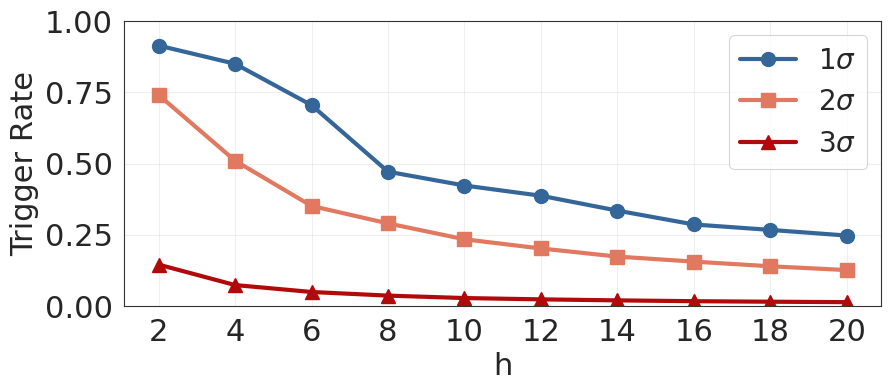

In [29]:
import matplotlib.pyplot as plt

# --- Style config ---
FIG_SIZE = (9, 4)
FONT_LABEL = 22
FONT_TICK = 22
FONT_LEGEND = 20
FONT_TITLE = 22

COLORS = {
    "1sigma": "#34669A",
    "2sigma": "#E0795F",
    "3sigma": "#B00A0B",
}

LABEL_MAP = {
    "1sigma": r"$1\sigma$",
    "2sigma": r"$2\sigma$",
    "3sigma": r"$3\sigma$",
}

# NEW: marker styles
MARKERS = {
    "1sigma": "o",   # circle
    "2sigma": "s",   # square
    "3sigma": "^",   # triangle
}

# --- Plot ---
plt.figure(figsize=FIG_SIZE)

for nu_name in sorted(res_df["nu_name"].unique()):
    sub = res_df[res_df["nu_name"] == nu_name]
    plt.plot(
        sub["h"],
        sub["trigger_rate"],
        marker=MARKERS.get(nu_name, "o"),
        linewidth=3,
        markersize=10,
        color=COLORS.get(nu_name, None),
        label=LABEL_MAP[nu_name]
    )

# --- Labels ---
plt.xlabel("h", fontsize=FONT_LABEL)
plt.ylabel("Trigger Rate", fontsize=FONT_LABEL)

# --- Ticks ---
plt.xticks(fontsize=FONT_TICK)
plt.xticks(h_list)
plt.yticks(fontsize=FONT_TICK)

# --- Legend ---
plt.legend(fontsize=FONT_LEGEND)

# --- Grid ---
plt.grid(alpha=0.3)

plt.ylim(0, 1)
plt.tight_layout()
plt.savefig("../data/figs/rq3_calibration_overview.pdf", bbox_inches="tight")
plt.show()

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def simulate_gt_with_reset(z, nu, h):
    G = 0.0
    triggers = []
    G_series = []
    increments = []

    for t in range(len(z)):
        inc = z[t] - nu
        G = max(0.0, G + inc)
        G_series.append(G)
        increments.append(inc)

        if G > h:
            triggers.append(t)
            G = 0.0

    return np.array(G_series), np.array(increments), triggers


def extract_config_trace(test_df, nu, h):
    z = test_df["z_evidence"].to_numpy(dtype=float)
    f1 = test_df["f1_score"].to_numpy(dtype=float) if "f1_score" in test_df.columns else None

    G_series, increments, triggers = simulate_gt_with_reset(z, nu, h)

    out = test_df.copy()
    out["G_t"] = G_series
    out["increment"] = increments
    out["is_trigger"] = 0
    if len(triggers) > 0:
        out.loc[out.index[triggers], "is_trigger"] = 1

    if f1 is not None:
        out["f1_score"] = f1

    return out, triggers

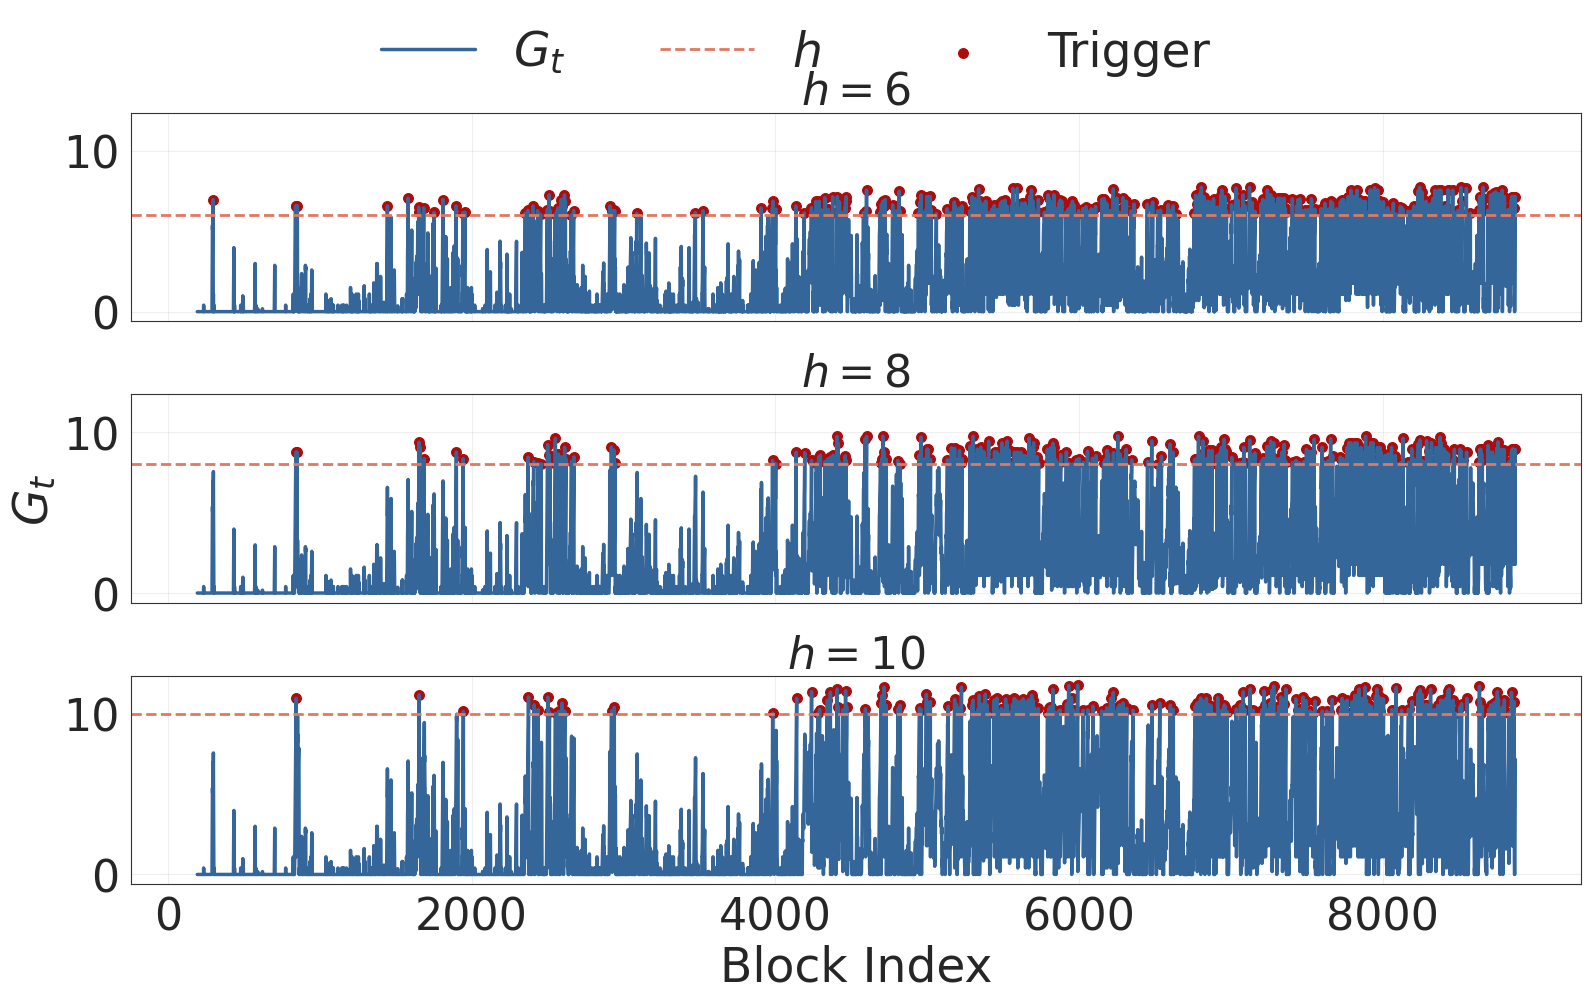

In [32]:
import matplotlib.pyplot as plt

# --- config ---
nu_name = "3sigma"
nu_value = nu_dict[nu_name]
compare_h = [6, 8, 10]

FIG_SIZE = (16, 10)
FONT_LABEL = 34
FONT_TICK =32
FONT_TITLE = 32

COLORS = {
    "Gt": "#34669A",
    "threshold": "#E0795F",
    "trigger": "#B00A0B",
}

# --- subplot ---
fig, axes = plt.subplots(len(compare_h), 1, figsize=FIG_SIZE, sharex=True, sharey=True)

for i, h in enumerate(compare_h):
    ax = axes[i]

    trace_df, triggers = extract_config_trace(test_df, nu_value, h)

    # G_t
    ax.plot(
        trace_df["block_index"],
        trace_df["G_t"],
        linewidth=2.5,
        color=COLORS["Gt"],
        label=r"$G_t$" if i == 0 else None   # only once
    )

    # threshold (label as generic "h")
    ax.axhline(
        h,
        linestyle="--",
        linewidth=2,
        color=COLORS["threshold"],
        label=r"$h$" if i == 0 else None
    )

    # triggers
    if len(triggers) > 0:
        trig_x = trace_df.iloc[triggers]["block_index"]
        trig_y = trace_df.iloc[triggers]["G_t"]

        ax.scatter(
            trig_x,
            trig_y,
            s=50,
            color=COLORS["trigger"],
            label="Trigger" if i == 0 else None
        )

    # y label only once
    if i == 1:   # center subplot
        ax.set_ylabel(r"$G_t$", fontsize=FONT_LABEL)

    # x label only at bottom
    if i == len(compare_h) - 1:
        ax.set_xlabel("Block Index", fontsize=FONT_LABEL)

    # ticks
    ax.tick_params(axis="both", labelsize=FONT_TICK)

    # subplot title
    ax.set_title(fr"$h={h}$", fontsize=FONT_TITLE)

# --- shared legend ---
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=3,
    fontsize=FONT_LABEL,
    frameon=False
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("../data/figs/rq3_operational_behaviour.pdf", bbox_inches="tight")
plt.show()